# Explainability with SHAP

This notebook explores model explainability for the COMPAS responsible AI audit.

The purpose is to understand which features influence the baseline model's predictions. Explainability does not make a model fair or ethically acceptable by itself, but it can help auditors examine model behavior, identify proxy variables, and communicate limitations more clearly.

This notebook uses:

- Logistic regression coefficients
- SHAP values
- Global feature importance
- Local explanation examples

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", None)

In [3]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

df = pd.read_csv(url)

df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [4]:
model_df = df[
    [
        "age",
        "age_cat",
        "juv_fel_count",
        "juv_misd_count",
        "juv_other_count",
        "priors_count",
        "c_charge_degree",
        "sex",
        "race",
        "two_year_recid"
    ]
].copy()

model_df.head()

,age,age_cat,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,sex,race,two_year_recid
0,69,Greater than 45,0,0,0,0,F,Male,Other,0
1,34,25 - 45,0,0,0,0,F,Male,African-American,1
2,24,Less than 25,0,0,1,4,F,Male,African-American,1
3,23,Less than 25,0,1,0,1,F,Male,African-American,0
4,43,25 - 45,0,0,0,2,F,Male,Other,0


## Define Features and Target + Train/Test Split

In [5]:
target = "two_year_recid"

feature_columns = [
    "age",
    "age_cat",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "c_charge_degree"
]

audit_columns = ["race", "sex"]

X = model_df[feature_columns]
y = model_df[target]
audit_data = model_df[audit_columns]

X.head()

,age,age_cat,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree
0,69,Greater than 45,0,0,0,0,F
1,34,25 - 45,0,0,0,0,F
2,24,Less than 25,0,0,1,4,F
3,23,Less than 25,0,1,0,1,F
4,43,25 - 45,0,0,0,2,F


In [6]:
X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X,
    y,
    audit_data,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5410
Testing rows: 1804


## Preprocessing & Logistic Regression

In [7]:
numeric_features = [
    "age",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count"
]

categorical_features = [
    "age_cat",
    "c_charge_degree"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'juv_fel_count',
                                                   'juv_misd_count',
                                                   'juv_other_count',
                                                   'priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat',
                                                   'c_charge_degree'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [8]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['num__age', 'num__juv_fel_count', 'num__juv_misd_count',
       'num__juv_other_count', 'num__priors_count',
       'cat__age_cat_25 - 45', 'cat__age_cat_Greater than 45',
       'cat__age_cat_Less than 25', 'cat__c_charge_degree_F',
       'cat__c_charge_degree_M'], dtype=object)

In [9]:
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()

if sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

X_test_transformed_df.head()

,num__age,num__juv_fel_count,num__juv_misd_count,num__juv_other_count,num__priors_count,cat__age_cat_25 - 45,cat__age_cat_Greater than 45,cat__age_cat_Less than 25,cat__c_charge_degree_F,cat__c_charge_degree_M
0,-0.407374,-0.141232,-0.191698,-0.209126,-0.302421,1.0,0.0,0.0,1.0,0.0
1,1.704037,-0.141232,-0.191698,-0.209126,0.713664,0.0,1.0,0.0,1.0,0.0
2,1.028386,-0.141232,-0.191698,-0.209126,-0.302421,0.0,1.0,0.0,1.0,0.0
3,-0.829656,-0.141232,-0.191698,-0.209126,-0.302421,1.0,0.0,0.0,1.0,0.0
4,1.619581,-0.141232,-0.191698,-0.209126,-0.302421,0.0,1.0,0.0,0.0,1.0


## Logistic Regression Coefficients

In [10]:
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients)
    }
).sort_values("absolute_coefficient", ascending=False)

coef_df

,feature,coefficient,absolute_coefficient
4,num__priors_count,0.768610,0.768610
0,num__age,-0.577763,0.577763
5,cat__age_cat_25 - 45,-0.224812,0.224812
9,cat__c_charge_degree_M,-0.134479,0.134479
6,cat__age_cat_Greater than 45,0.099750,0.099750
1,num__juv_fel_count,0.090297,0.090297
3,num__juv_other_count,0.088052,0.088052
8,cat__c_charge_degree_F,0.050041,0.050041
7,cat__age_cat_Less than 25,0.040624,0.040624
2,num__juv_misd_count,-0.000982,0.000982


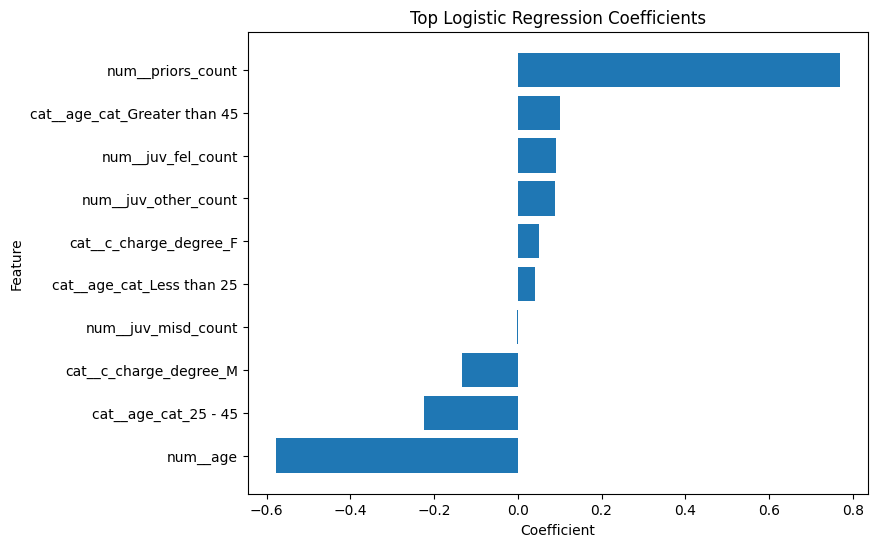

In [11]:
top_coef_df = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_coef_df["feature"], top_coef_df["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## Coefficient Interpretation

Logistic regression coefficients show the direction and relative strength of each feature's association with the predicted outcome.

Positive coefficients increase the model's predicted likelihood of two-year recidivism. Negative coefficients decrease the predicted likelihood.

These coefficients should be interpreted carefully because they reflect associations in the data, not causal relationships.

## SHAP Explainer

In [12]:
classifier = model.named_steps["classifier"]

explainer = shap.LinearExplainer(
    classifier,
    X_train_transformed_df
)

shap_values = explainer(X_test_transformed_df)

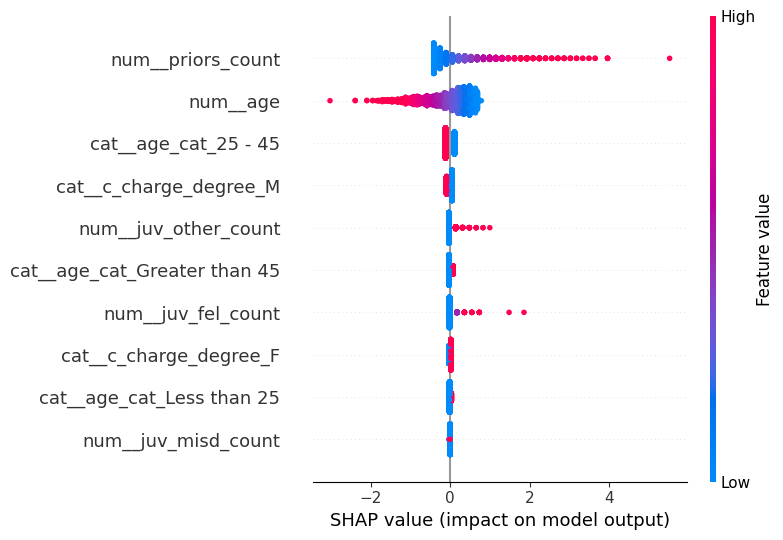

In [13]:
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    show=True
)

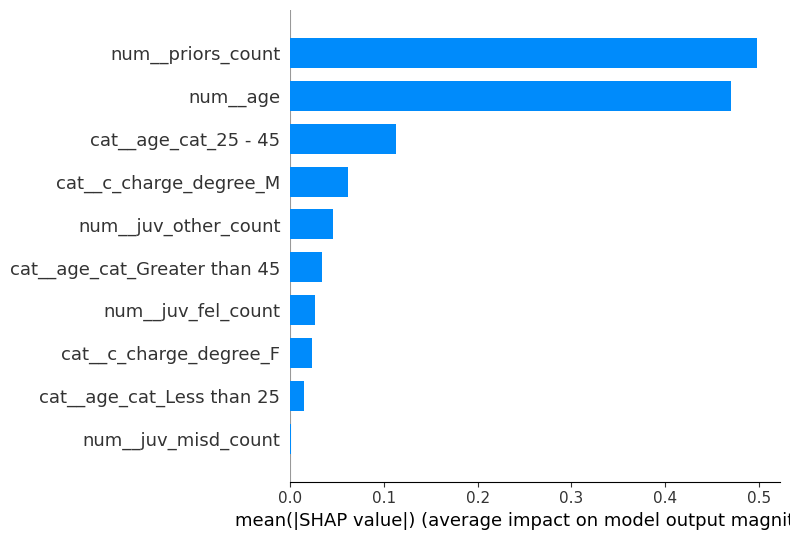

In [14]:
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    plot_type="bar",
    show=True
)

## SHAP Interpretation

SHAP values estimate how much each feature contributes to a model prediction.

The summary plot shows both feature importance and the direction of influence. Features with larger SHAP values have greater influence on model predictions.

In a responsible AI audit, SHAP can help identify which variables are driving predictions and whether those variables may act as proxies for sensitive or protected characteristics.

## Taking a Look at Local Explanations

In [15]:
case_index = 0

X_test.iloc[[case_index]]

,age,age_cat,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree
6421,30,25 - 45,0,0,0,2,F


In [16]:
audit_test.iloc[[case_index]]

,race,sex
6421,African-American,Male


In [17]:
prediction = model.predict(X_test.iloc[[case_index]])[0]
probability = model.predict_proba(X_test.iloc[[case_index]])[0, 1]

print("Prediction:", prediction)
print("Predicted probability of two-year recidivism:", probability)

Prediction: 0
Predicted probability of two-year recidivism: 0.42773338860402116


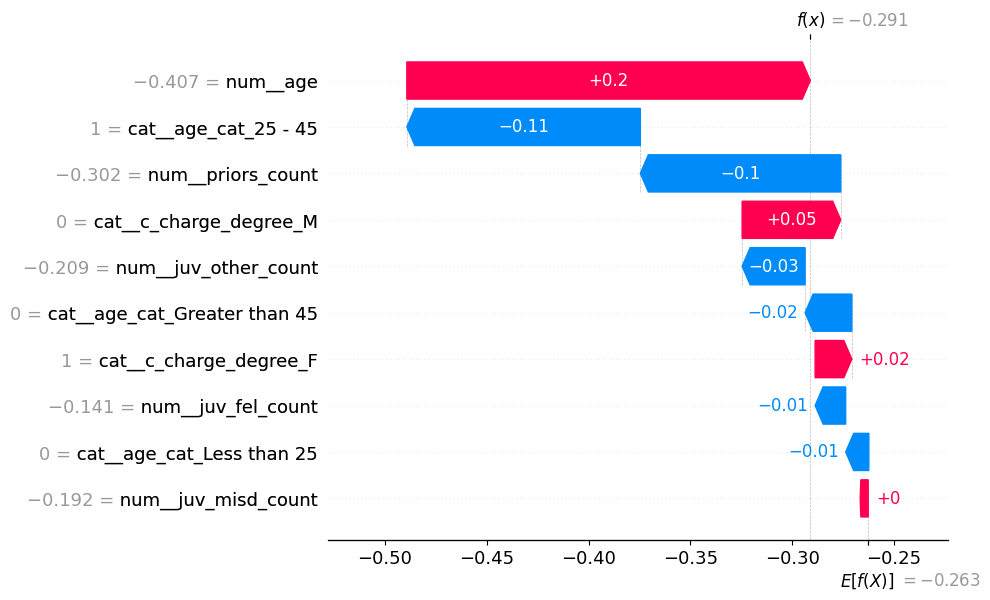

In [18]:
shap.plots.waterfall(shap_values[case_index])

## Local Explanation

The waterfall plot explains one individual prediction by showing which features pushed the prediction higher or lower.

Local explanations can be useful for auditing, but they should not be treated as a complete justification for high-stakes decisions. In sensitive contexts, explanations must be paired with fairness evaluation, domain expertise, and ethical review.

## Explainability Summary

This notebook used logistic regression coefficients and SHAP values to examine the baseline model.

The most important lesson is that explainability is not the same as fairness. A model can be explainable and still produce harmful or inequitable outcomes.

Explainability tools are most useful when combined with subgroup performance analysis, careful documentation, and responsible deployment review.